## 黒潮周辺におけるカルマンフィルタ


In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns

## パラメータの設定

In [11]:
deg_per_mesh = 1/36
ais_lat_max = 1800
ais_lat_min = 750
ais_lon_max = 5401
ais_lon_min = 4211
lat_range = [20-1/36, 50+1/36]
lon_range = [117-1/36, 150+1/36]
map_size_ais = [1050, 1191]
map_size_jcope = [1082, 1191]

### 論文を参考に黒潮付近を設定
黒潮付近<br>
(32, 130), (30, 130), (34, 142), (36,　142)

In [79]:
kurosio_lat_range1 = [30, 32]
kurosio_lat_range2 = [34, 36]
kurosio_lon_range = [130, 142]
line1 = [[kurosio_lat_range1[0], kurosio_lon_range[0]], [kurosio_lat_range2[0], kurosio_lon_range[1]]]
line2 = [[kurosio_lat_range2[0], kurosio_lon_range[1]], [kurosio_lat_range2[1], kurosio_lon_range[1]]]
line3 = [[kurosio_lat_range2[1], kurosio_lon_range[1]], [kurosio_lat_range1[1], kurosio_lon_range[0]]]
line3 = [[kurosio_lat_range1[1], kurosio_lon_range[0]], [kurosio_lat_range1[0], kurosio_lon_range[0]]]

kurosio_row_range1 = [int((kurosio_lat_range1[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range1[1]-lat_range[0])/deg_per_mesh)]
kurosio_row_range2 = [int((kurosio_lat_range2[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range2[1]-lat_range[0])/deg_per_mesh)]
kurosio_col_range = [int((kurosio_lon_range[0]-lon_range[0])/deg_per_mesh), int((kurosio_lon_range[1]-lon_range[0])/deg_per_mesh)]

## 関数の定義

In [150]:
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = lat_range
    lon_range = lon_range
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[1])/deg_per_mesh)
    grid1 = int((lat-lat_range[0])/deg_per_mesh)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*deg_per_mesh

def kurosio(row, col):
    dx = kurosio_col_range[1]-kurosio_col_range[0]
    dy1 = kurosio_row_range2[0] - kurosio_row_range1[0]
    a1 = dy1/dx
    b1 = kurosio_row_range1[0] - a1*kurosio_col_range[0]
    dy2 = kurosio_row_range2[1] - kurosio_row_range1[1]
    a2 = dy2/dx
    b2 = kurosio_row_range1[1] - a1*kurosio_col_range[0]
    
    if(col<kurosio_col_range[0] or col>kurosio_col_range[1]):
        return False
    if(a1*col+b1 > row or a2*col+b2 < row):
        return False
    return True

def kurosio_filter(data, marine_map):
    res = []
    for i in range(map_size_ais[0]):
        for j in range(map_size_ais[1]):
            if kurosio(i, j) and marine_map[i][j]==marine_map[i][j]:
                res.append(data[i][j])
    return np.array(res)

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

# 黒潮マップ
kurosio_map = np.zeros((map_size_ais)) * np.nan
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map[map_size_ais[0]-i][j] = 1

kurosio_map_tf = np.zeros((map_size_ais)) == 1 
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map_tf[map_size_ais[0]-i][j] = True

## データの読み込み

In [23]:
# pathの設定
path_ais = [ fr'./data/ais/20150919\150919-{i+1}log\log' for i in range(12)]
path_jcope = [fr'./data/eas\2015091900{i}' for i in range(24)]

# AIS (MAP curN, curE)
date = [i for i in range(1817, 1824, 2)] + [i for i in range(1900, 1916, 2)]
ais_n_mapped = []
for i, p in enumerate(path_ais):
    ais_n_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"N.csv", encoding="cp932",))
ais_e_mapped = []
for i, p in enumerate(path_ais):
    ais_e_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"E.csv", encoding="cp932",))

    
# JCOPE (MAP curN, curE)
jcope_n = []
for p in path_jcope:
    jcope_n.append(pd.read_csv(p+"/N.csv", encoding="cp932",))
jcope_e = []
for p in path_jcope:
    jcope_e.append(pd.read_csv(p+"/E.csv", encoding="cp932",))


In [24]:
for i in range(len(jcope_n)):
    jcope_n[i] = jcope_n[i][0:1050]

for i in range(len(jcope_e)):
    jcope_e[i] = jcope_e[i][0:1050]

nan_map = np.array(jcope_n[0])*0+1

## 黒潮領域の確認

Kurosio:(1050, 1191)


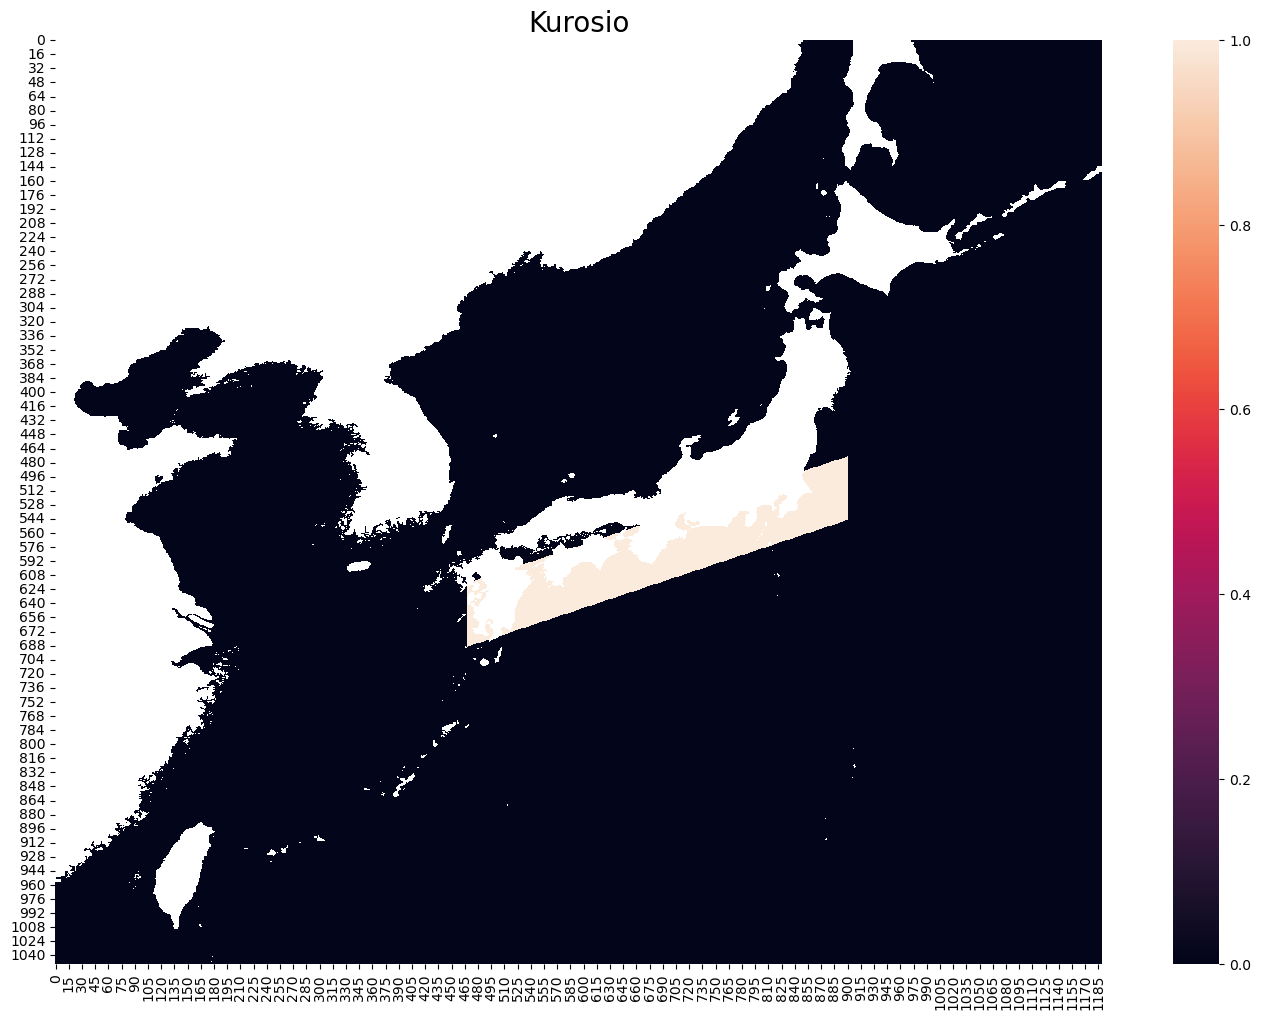

In [126]:
datas = [kurosio_map_tf*nan_map]
data_names = ['Kurosio']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()

全データの可視化

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1050, 1191)
JCOPE E:(1050, 1191)


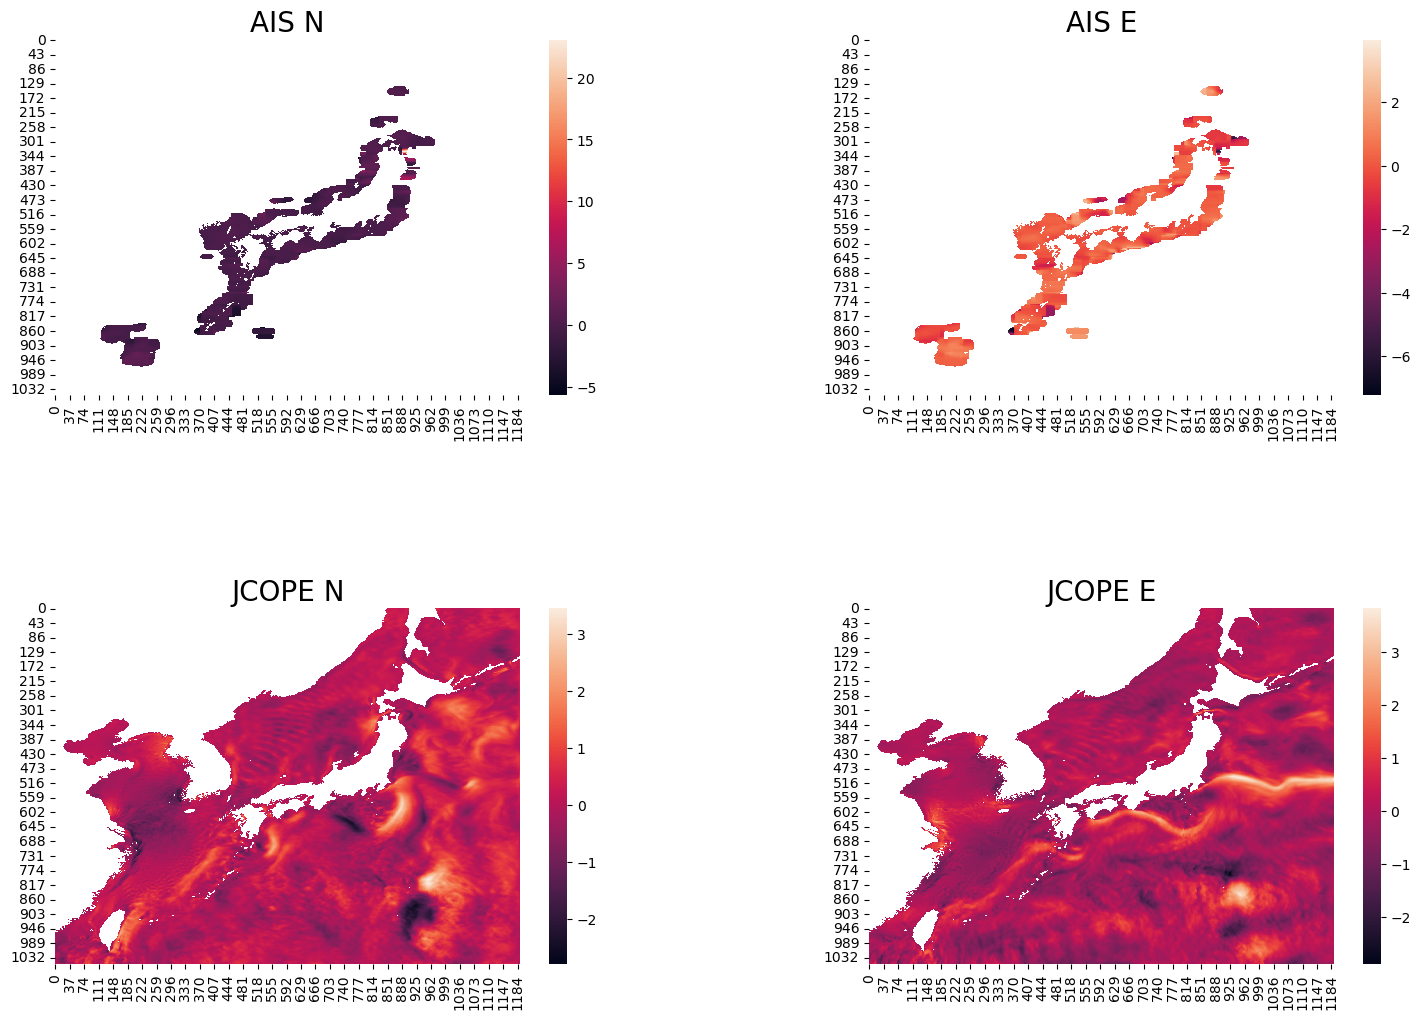

In [20]:
datas = [ais_n_mapped[0], ais_e_mapped[0], jcope_n[0], jcope_e[0]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

黒潮のみ可視化

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1050, 1191)
JCOPE E:(1050, 1191)


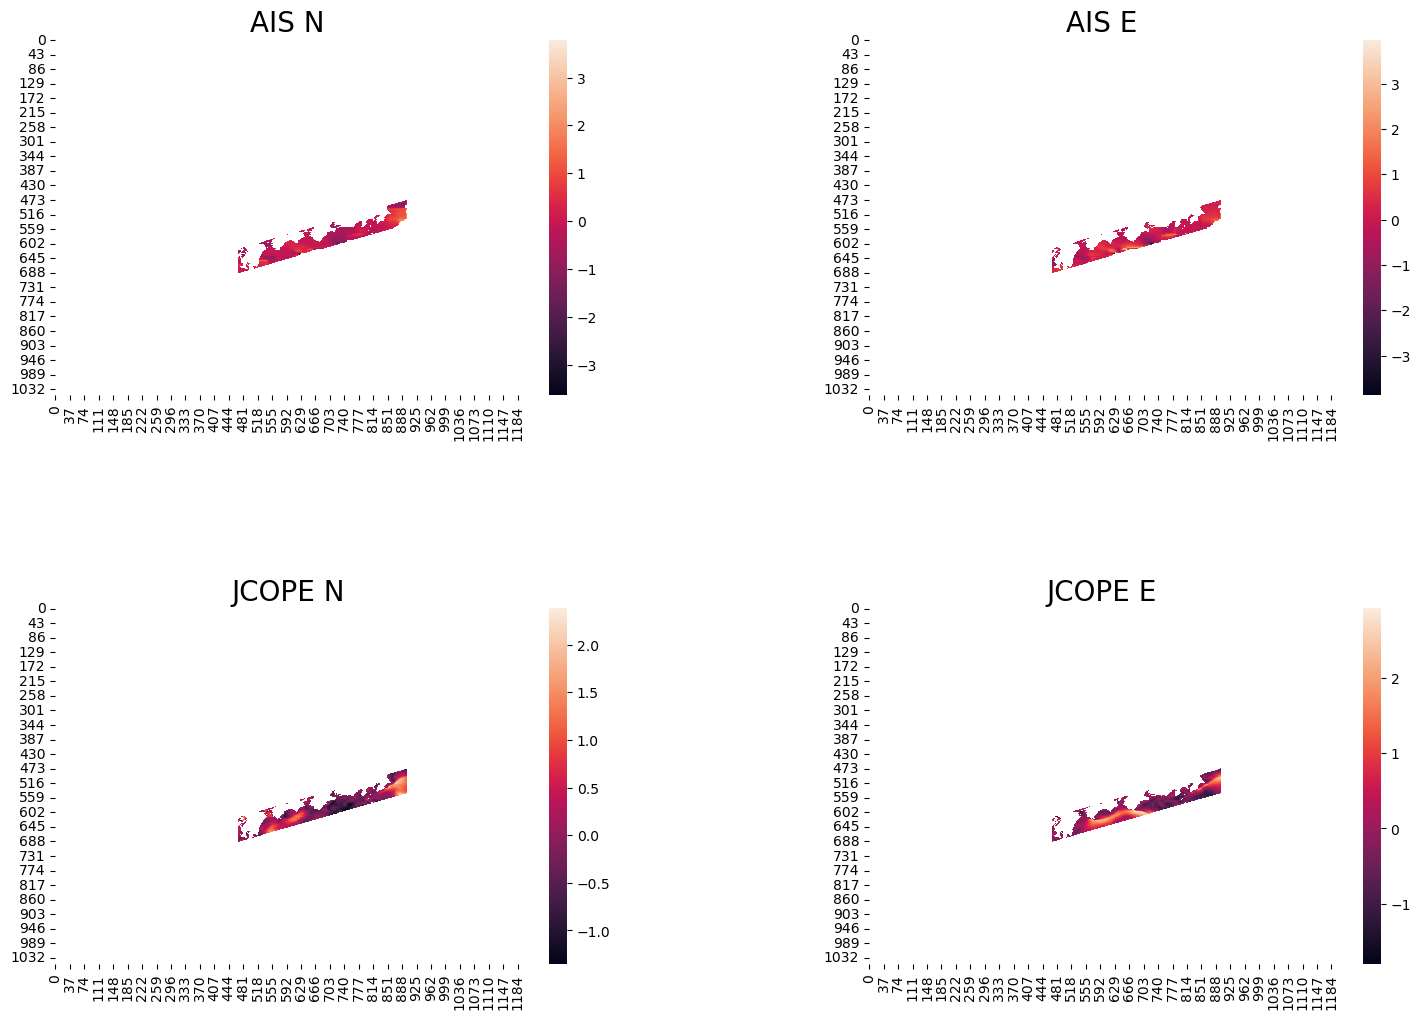

In [128]:
datas = [ais_n_mapped[0]*kurosio_map, 
         ais_e_mapped[0]*kurosio_map, 
         jcope_n[0]*kurosio_map, 
         jcope_e[0]*kurosio_map]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

黒潮領域のデータ数(陸地を除く)は22583<br>
存在しないデータが半数以上あるので，もっと計算量を小さくはできる<br>
ちなみに，陸地込みの場合は31321<br>

In [157]:
# 黒潮領域のデータ数の確認
datas = [kurosio_filter(ais_n_mapped[0].values, nan_map), 
         kurosio_filter(ais_e_mapped[0].values, nan_map), 
         kurosio_filter(jcope_n[0].values, nan_map),
         kurosio_filter(jcope_e[0].values, nan_map)]
data_name = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
for i, d in enumerate(datas):
    print(f"データ名: {data_name[i]}, データ数:{len(d)}, 存在しないデータ数: {np.sum(d!=d)}")

データ名: AIS N, データ数:22583, 存在しないデータ数: 14657
データ名: AIS E, データ数:22583, 存在しないデータ数: 14657
データ名: JCOPE N, データ数:22583, 存在しないデータ数: 0
データ名: JCOPE E, データ数:22583, 存在しないデータ数: 0


## 黒潮領域のカルマンフィルター
aisの信頼度のデータを計算するの忘れたので，とりあえず誤差の値は0.01にする

In [161]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

data = kurosio_filter(ais_n_mapped[0].values, nan_map)
n = len(data)
m = 1

def F_element(i, j, k, data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        jcope0 = data[k-1]
        jcope1 = data[k]
        residual = jcope1[i] - jcope0[i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    
def R_mat(sigma):
    R = np.zeros((n*m+1, n*m+1))
    for i in range(len(sigma)):
        R[i][i] = sigma[i]
    return R


kf = KalmanFilter(dim_x=n*m+1, dim_z=n*m+1)
ais_n0 = kurosio_filter(ais_n_mapped[0]) # 時刻0のais data
jcope_n0 = kurosio_filter(jcope_n[0]) # 時刻0のjcope data

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_n0)  for i in range(n*m+1)] for j in range(n*m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])


# 分散共分散行列
kf.Q = np.eye(n*m+1)*0.001 # システム誤差(ais)
#kf.R = R_mat(ais_sigmas2[0]) # 観測誤差(jcope)
kf.R = np.eye(n*m+1)*0.001

kf.x = jcope_n0 # 初期位置
kf.P = np.eye(n*m+1) # 初期事後誤差共分散行列
s = Saver(kf) # save用
for t in tqdm.tqdm(range(1, len(jcope_n)-1)):
    # 予測ステップ
    kf.predict()
    
    # フィルタリングステップ
    # kf.R = R_mat(ais_sigmas2[t])
    kf.R = np.eye(n*m+1)*0.001
    y = kurosio_filter(ais_n_mapped[t], nan_map)
    # nanの処理と誤差の最大化
    kf.update(y)
    
    """
    target = 88
    if y[target]!=0.0:
        print(f"t:{t}")
        print(f"R:{kf.R[target][target]}")
        print(f"x:{kf.x[target]}")
        print(f"y:{y[target]}") 
    """
    
    s.save()  # 現在状態を記録する
    t += 1
    
    # 関数の更新
    x = kurosio_filter(jcope_n[t], nan_map)
    kf.F = np.array([[F_element(i, j, t, x)  for i in range(n*m+1)] for j in range(n*m+1)])
    kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 8
j = 8
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel(f"({i}, {j}) value")
plt.plot(np.arange(len(s.x[:, i+(j*n)])), s.x[:, i+(j*n)], label='res')
plt.scatter(np.arange(len(s.x[:, i+(j*n)])), s.z[:, i+(j*n)], label='obs', c='r')
plt.legend()
plt.show()

MemoryError: Unable to allocate 3.80 GiB for an array with shape (22584, 22584) and data type float64